In [400]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [412]:
df = pd.read_csv(r"..\csv\cleaned_data.csv")
print("Forma del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Forma del dataset: (30552, 14)

Primeras filas:


,Campaña,Pedido,Zona,Dirección entrega,Telefono,Barrio,Ciudad,Fecha recibo LD,Fecha reparto,Fecha entrega,Transportador,Estado,horas_entrega,umbral
0,202407,37087842,601,KR 47A 48 39- TEL 0-3143423923,0-3143423923,CORDOBA,CALI (VALLE),2024-04-27 19:07:31,2024-04-29 10:43:16,2024-04-29 22:08:43,CBZ922,A TIEMPO,11.424167,24
1,202407,37093297,580,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,COMFENALCO,CALI (VALLE),2024-04-27 19:04:43,2024-04-28 10:24:04,2024-04-28 16:40:32,TZY274,A TIEMPO,6.274444,24
2,202407,37098642,594,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,PROVIVIENDA,DAGUA (VALLE),2024-04-28 20:40:40,2024-04-29 11:18:40,2024-04-30 12:00:25,TZN919,A TIEMPO,24.695833,48
3,202407,37105003,603,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,CARLOS GUZMAN,PUERTO TEJADA (CAUCA),2024-05-04 09:36:18,2024-05-04 13:10:03,2024-05-05 23:00:44,CEN356,A TIEMPO,33.844722,48
4,202407,37111291,603,KR 18 15 A 40- TEL 0-3125418458,0-3125418458,LA SAMARIA,SANTANDER DE QUILICHAO (CAUCA),2024-05-04 09:18:31,2024-05-06 08:39:17,2024-05-06 22:00:29,TZY274,A TIEMPO,13.353333,48


In [413]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30552 entries, 0 to 30551
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaña            30552 non-null  int64  
 1   Pedido             30552 non-null  int64  
 2   Zona               30552 non-null  object 
 3   Dirección entrega  30552 non-null  object 
 4   Telefono           30552 non-null  object 
 5   Barrio             30552 non-null  object 
 6   Ciudad             30552 non-null  object 
 7   Fecha recibo LD    30552 non-null  object 
 8   Fecha reparto      30552 non-null  object 
 9   Fecha entrega      30552 non-null  object 
 10  Transportador      30552 non-null  object 
 11  Estado             30552 non-null  object 
 12  horas_entrega      30552 non-null  float64
 13  umbral             30552 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


## Seleccion y arreglo de Features

In [414]:
# Seleccionar columnas relevantes
columnas_usar = ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 
                  'Transportador']

df_modelo = df[columnas_usar].copy()
print("Columnas a usar:", columnas_usar)
print("\nTipos de datos:")
print(df_modelo.dtypes)
print("\nValores únicos por columna:")
for col in df_modelo.columns:
    print(f"{col}: {df_modelo[col].nunique()} valores únicos")

Columnas a usar: ['Zona', 'Barrio', 'Ciudad', 'Fecha recibo LD', 'Transportador']

Tipos de datos:
Zona               object
Barrio             object
Ciudad             object
Fecha recibo LD    object
Transportador      object
dtype: object

Valores únicos por columna:
Zona: 9 valores únicos
Barrio: 709 valores únicos
Ciudad: 36 valores únicos
Fecha recibo LD: 28095 valores únicos
Transportador: 24 valores únicos


In [415]:
df_modelo['Fecha recibo LD'] = pd.to_datetime(df_modelo['Fecha recibo LD'])


In [416]:
df_modelo["hora_recibo"] = df_modelo["Fecha recibo LD"].dt.hour
df_modelo["dia_semana_recibo"] = df_modelo["Fecha recibo LD"].dt.dayofweek
df_modelo["mes"] = df_modelo["Fecha recibo LD"].dt.month


In [417]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30552 entries, 0 to 30551
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Zona               30552 non-null  object        
 1   Barrio             30552 non-null  object        
 2   Ciudad             30552 non-null  object        
 3   Fecha recibo LD    30552 non-null  datetime64[ns]
 4   Transportador      30552 non-null  object        
 5   hora_recibo        30552 non-null  int32         
 6   dia_semana_recibo  30552 non-null  int32         
 7   mes                30552 non-null  int32         
dtypes: datetime64[ns](1), int32(3), object(4)
memory usage: 1.5+ MB


In [418]:
df_modelo = df_modelo.drop(columns=["Fecha recibo LD",])

In [419]:
salida = df['horas_entrega']

## Split train-test

In [420]:
x_train, x_test, y_train, y_test = train_test_split(df_modelo, salida, test_size=0.3, random_state=0)

In [421]:
print("x_train: ",x_train.shape)
print("y_train: ",y_train.shape)
print("x_test: ",x_test.shape)
print("y_test: ",y_test.shape)

x_train:  (21386, 7)
y_train:  (21386,)
x_test:  (9166, 7)
y_test:  (9166,)


## Barrio Target Encoding

In [422]:
barrio_mean = y_train.groupby(x_train["Barrio"]).mean()

x_train["barrio_encoded"] = x_train["Barrio"].map(barrio_mean)
x_test["barrio_encoded"] = x_test["Barrio"].map(barrio_mean)

global_mean = y_train.mean()

x_train["barrio_encoded"] = x_train["barrio_encoded"].fillna(global_mean)
x_test["barrio_encoded"] = x_test["barrio_encoded"].fillna(global_mean)

In [423]:
x_train = x_train.drop(columns=["Barrio"])
x_test = x_test.drop(columns=["Barrio"])

## One Hot Encoding a columnas categoricas

In [424]:
columnas_ohe = [
    "Ciudad",
    "Transportador",
]

In [425]:
x_train = pd.get_dummies(x_train, columns=columnas_ohe, drop_first=True)
x_test = pd.get_dummies(x_test, columns=columnas_ohe, drop_first=True)
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [426]:
le_zona = LabelEncoder()

x_train["Zona_encoded"] = le_zona.fit_transform(x_train["Zona"])
x_test["Zona_encoded"] = le_zona.transform(x_test["Zona"])

In [427]:
x_train = x_train.drop(columns=["Zona"])
x_test = x_test.drop(columns=["Zona"])

## Escalado y entrenamiento del modelo

In [428]:
print(x_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 21386 entries, 554 to 2732
Data columns (total 62 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   hora_recibo                               21386 non-null  int32  
 1   dia_semana_recibo                         21386 non-null  int32  
 2   mes                                       21386 non-null  int32  
 3   barrio_encoded                            21386 non-null  float64
 4   Ciudad_BOGOTA (CUNDINAMARCA)              21386 non-null  bool   
 5   Ciudad_BUENOS AIRES CAUCA                 21386 non-null  bool   
 6   Ciudad_CALI (VALLE)                       21386 non-null  bool   
 7   Ciudad_CALOTO (CAUCA)                     21386 non-null  bool   
 8   Ciudad_CANDELARIA VALLE DEL CAUCA         21386 non-null  bool   
 9   Ciudad_CODAZZI (CESAR)                    21386 non-null  bool   
 10  Ciudad_CORINTO (CAUCA)                

In [429]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=11,
    random_state=42,
    n_jobs=-1
)

In [430]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,11
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [431]:
y_pred_rf = rf.predict(x_test)

## Metricas y graficas

In [432]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest:
MAE: 9.015298721995794
RMSE: 13.391055181341656
R2: 0.6066922988890484


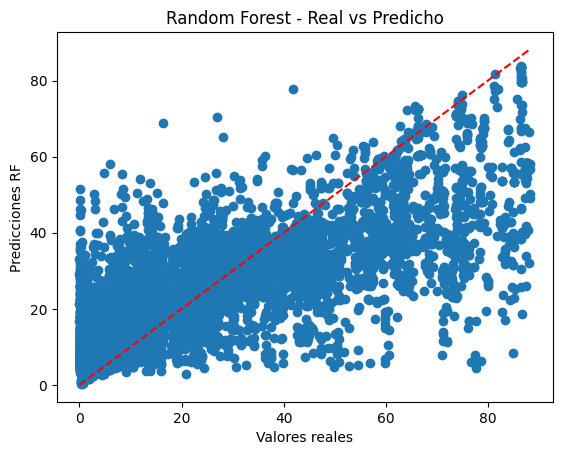

In [433]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='red')
plt.xlabel("Valores reales")
plt.ylabel("Predicciones RF")
plt.title("Random Forest - Real vs Predicho")
plt.show()

In [434]:
importancias = pd.Series(rf.feature_importances_, index=x_train.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias.head(10))

barrio_encoded          0.396278
mes                     0.120891
hora_recibo             0.098370
dia_semana_recibo       0.095935
Transportador_TZY274    0.078146
Zona_encoded            0.036836
Transportador_WHU392    0.030776
Transportador_FJM605    0.021073
Transportador_YAB292    0.015704
Ciudad_CALI (VALLE)     0.013593
dtype: float64


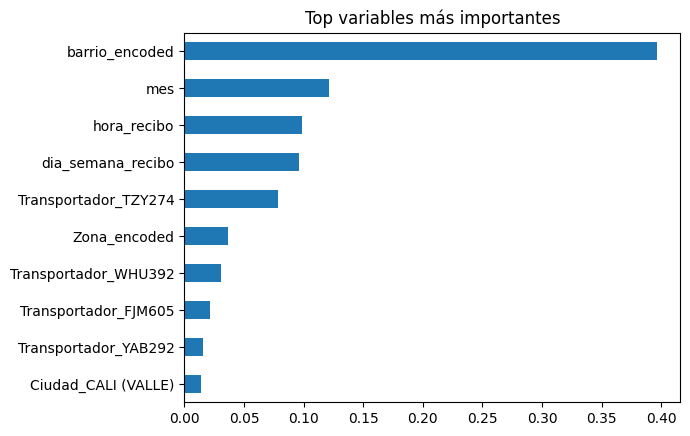

In [435]:
plt.figure()
importancias.head(10).plot(kind='barh')
plt.title("Top variables más importantes")
plt.gca().invert_yaxis()
plt.show()

## Creacion de umbral para matriz de confusion

In [436]:
umbral = np.where(
    x_test["Ciudad_CALI (VALLE)"] == 1,
    24,
    48
)

In [437]:
y_test_clase = (y_test <= umbral).astype(int)
y_pred_clase = (y_pred_rf <= umbral).astype(int)

In [438]:
cm = confusion_matrix(y_test_clase, y_pred_clase)
print(cm)

[[1519  615]
 [ 703 6329]]


In [439]:
print(classification_report(y_test_clase, y_pred_clase))

              precision    recall  f1-score   support

           0       0.68      0.71      0.70      2134
           1       0.91      0.90      0.91      7032

    accuracy                           0.86      9166
   macro avg       0.80      0.81      0.80      9166
weighted avg       0.86      0.86      0.86      9166



In [440]:
y_pred_train = rf.predict(x_train)

from sklearn.metrics import r2_score
print("R2 train:", r2_score(y_train, y_pred_train))
print("R2 test:", r2_score(y_test, y_pred_rf))

R2 train: 0.6996445391165107
R2 test: 0.6066922988890484


## XGBoost

In [441]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [469]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

In [470]:
xgb.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [471]:
y_pred = xgb.predict(x_test)

In [472]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost:
MAE: 6.906237915368807
RMSE: 10.929784451649393
R2: 0.7379850660825854


In [473]:
y_true_class = (y_test <= umbral).astype(int)
y_pred_class = (y_pred <= umbral + 7).astype(int)

In [474]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true_class, y_pred_class)
print(cm)

print("\n")
print(classification_report(y_true_class, y_pred_class))

[[1319  815]
 [ 122 6910]]


              precision    recall  f1-score   support

           0       0.92      0.62      0.74      2134
           1       0.89      0.98      0.94      7032

    accuracy                           0.90      9166
   macro avg       0.90      0.80      0.84      9166
weighted avg       0.90      0.90      0.89      9166



In [475]:
# Predicciones
y_train_pred = xgb.predict(x_train)
y_test_pred = xgb.predict(x_test)

# R²
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("R² Train:", r2_train)
print("R² Test:", r2_test)
print("Diferencia:", r2_train - r2_test)

R² Train: 0.8354102636720555
R² Test: 0.7379850660825854
Diferencia: 0.0974251975894701
